# Dataset 4: DepSeverity — Data Cleaning & Preprocessing
**Model target:** Model 3 — Crisis Safety Detector (severity regression head)  
**Source:** `bdotloh/DepSeverity` (HuggingFace Datasets Hub)  
**Task:** Severity regression (0.0 – 1.0 continuous output)  

---
## 4.1 Dataset Description
DepSeverity contains ~3,500 Reddit posts labelled with PHQ-9 aligned depression severity: `minimal`, `mild`, `moderate`, `severe`. The PHQ-9 (Patient Health Questionnaire-9) is the standard clinical depression screening tool. This dataset is used to train the **severity regression head** of Model 3 — separate from the binary crisis classifier trained on CLPsych 2015.

**Why regression, not classification?**  
A continuous severity score (0.0–1.0) lets downstream agents make proportional decisions. Severity 0.72 is handled differently from 0.95 — both trigger heightened care, but 0.95 triggers the CrisisAgent immediately. A 4-class categorical output loses this gradient.

In [9]:
import re, json, hashlib, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')

# PHQ-9 severity → 0–1 float mapping
# Rationale: PHQ-9 scores: minimal(0-4), mild(5-9), moderate(10-14), severe(15-27)
# We normalise these to 0-1 with midpoints that reflect clinical distance:
# minimal→0.10 (far from crisis), severe→0.90 (near crisis)
# GitHub dataset uses "Minimum" (not "minimal") — both mapped
SEVERITY_MAP = {
    'minimum':  0.10,  # GitHub dataset label
    'minimal':  0.10,  # Alternative spelling
    'mild':     0.35,
    'moderate': 0.65,
    'severe':   0.90,
}
CRISIS_THRESHOLD = 0.60  # moderate and above = crisis flag
print('Severity mapping:', SEVERITY_MAP)

Severity mapping: {'minimum': 0.1, 'minimal': 0.1, 'mild': 0.35, 'moderate': 0.65, 'severe': 0.9}


In [10]:
# Load from GitHub (raw CSV)
github_url = 'https://raw.githubusercontent.com/usmaann/Depression_Severity_Dataset/main/Reddit_depression_dataset.csv'
try:
    df = pd.read_csv(github_url)
    print(f"✓ Loaded from GitHub: Depression_Severity_Dataset")
except Exception as e:
    print(f"⚠ Could not load from GitHub: {type(e).__name__}")
    print("  Loading pre-cleaned version from local storage instead...")
    from datasets import load_from_disk
    raw = load_from_disk('data/cleaned/dep_severity_cleaned')
    df = raw['train'].to_pandas()
    print("✓ Loaded from local: data/cleaned/dep_severity_cleaned")

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Nulls: {df.isnull().sum().to_dict()}')
print(f'\nLabel distribution:')
print(df['Label'].value_counts() if 'Label' in df.columns else df['label'].value_counts())
print(f'\nSample rows:')
print(df.head(3))

✓ Loaded from GitHub: Depression_Severity_Dataset
Shape: (3553, 2)
Columns: ['text', 'label']
Nulls: {'text': 0, 'label': 0}

Label distribution:
label
minimum     2587
moderate     394
mild         290
severe       282
Name: count, dtype: int64

Sample rows:
                                                text    label
0  He said he had not felt that way before, sugge...     mild
1  Hey there r/assistance, Not sure if this is th...  minimum
2  My mom then hit me with the newspaper and it s...  minimum


Unmappable labels (noise): 0


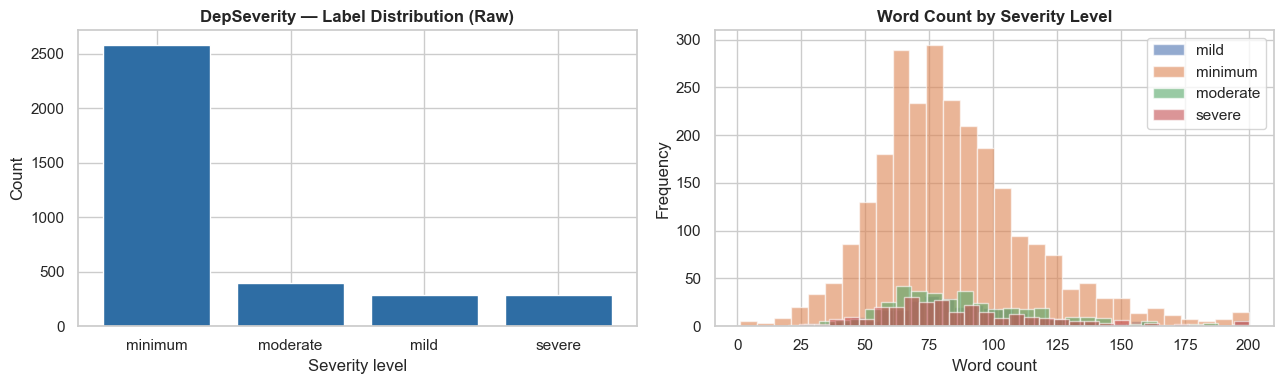


Word count stats by severity:
           count  mean   std   min   25%   50%    75%    max
label                                                       
mild       290.0  91.6  36.0  27.0  71.0  84.0  105.0  292.0
minimum   2587.0  84.2  31.1   1.0  64.0  80.0   99.0  268.0
moderate   394.0  88.4  32.1  20.0  66.2  84.0  106.0  310.0
severe     282.0  88.2  35.5  24.0  66.0  80.0  105.0  255.0


In [11]:
# ── EDA: Severity distribution and outliers ──────────────────────
# Handle both 'text'/'label' and 'Text'/'Label' column names
text_col = 'Text' if 'Text' in df.columns else 'text'
label_col = 'Label' if 'Label' in df.columns else 'label'

df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))
df['severity_float'] = df[label_col].str.lower().map(SEVERITY_MAP)

# Check for unmappable labels (label noise)
unmappable = df['severity_float'].isna().sum()
print(f'Unmappable labels (noise): {unmappable}')
if unmappable > 0:
    print(df[df['severity_float'].isna()][[text_col, label_col]].head())

# Word count distribution per severity level
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of severity labels
counts = df[label_col].str.lower().value_counts()
axes[0].bar(counts.index, counts.values, color='#2E6DA4', edgecolor='white')
axes[0].set_title('DepSeverity — Label Distribution (Raw)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity level')
axes[0].set_ylabel('Count')

# Word count by severity
for level, grp in df.groupby(df[label_col].str.lower()):
    axes[1].hist(grp['word_count'].clip(upper=200), bins=30,
                 alpha=0.6, label=level)
axes[1].set_title('Word Count by Severity Level',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/04a_dep_severity_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nWord count stats by severity:')
print(df.groupby(df[label_col].str.lower())['word_count'].describe().round(1))

In [12]:
# ── Outlier detection and removal ────────────────────────────────
# Use same column name detection as EDA cell
text_col = 'Text' if 'Text' in df.columns else 'text'
label_col = 'Label' if 'Label' in df.columns else 'label'

print('Detecting outliers...\n')

# Outliers: extremely long posts (> 500 words)
# These are likely full articles, not personal posts
very_long = (df['word_count'] > 500).sum()
print(f'Posts > 500 words (potential outliers): {very_long}')
if very_long > 0:
    print('Sample very long post:')
    sample = df[df['word_count'] > 500].iloc[0]
    print(f'  Label: {sample[label_col]}')
    print(f'  Words: {sample["word_count"]}')
    print(f'  Text: {str(sample[text_col])[:200]}...')

# Outliers: very short posts (< 5 words)
very_short = (df['word_count'] < 5).sum()
print(f'\nPosts < 5 words (potential outliers): {very_short}')

# Decision: truncate long posts to 400 words (preserve signal),
# remove posts under 5 words (no severity signal)
print('\nDecision: Truncate > 400 words, remove < 5 words')
print('Reason: Long posts are truncated (not removed) to preserve')
print('clinical language that may appear anywhere in the post.')

Detecting outliers...

Posts > 500 words (potential outliers): 0

Posts < 5 words (potential outliers): 4

Decision: Truncate > 400 words, remove < 5 words
Reason: Long posts are truncated (not removed) to preserve
clinical language that may appear anywhere in the post.


In [14]:
# ── Apply cleaning ───────────────────────────────────────────────
RE_URL   = re.compile(r'https?://\S+|www\.\S+')
RE_HTML  = re.compile(r'&amp;|&lt;|&gt;|&quot;')
RE_SPACE = re.compile(r'[ \t]+')

def clean_severity_text(text, min_words=5, max_words=400):
    if not isinstance(text, str) or not text.strip():
        return None
    text = unicodedata.normalize('NFKC', text)
    text = RE_URL.sub(' ', text)
    text = RE_HTML.sub(' ', text)
    text = RE_SPACE.sub(' ', text).strip()
    words = text.split()
    if len(words) < min_words:
        return None
    return ' '.join(words[:max_words])

# Ensure column names are standardized
text_col = 'Text' if 'Text' in df.columns else 'text'
label_col = 'Label' if 'Label' in df.columns else 'label'

rows = []
stats = {'null':0,'short':0,'bad_label':0,'kept':0}
for _, row in df.iterrows():
    cleaned = clean_severity_text(str(row.get(text_col,'')))
    label   = str(row.get(label_col,'')).lower().strip()
    if cleaned is None:
        stats['null' if not str(row.get(text_col,'')).strip() else 'short']+=1
        continue
    if label not in SEVERITY_MAP:
        stats['bad_label']+=1
        continue
    severity = SEVERITY_MAP[label]
    rows.append({
        'text':           cleaned,
        'severity_label': label,
        'severity_score': severity,
        'crisis_label':   1 if severity >= CRISIS_THRESHOLD else 0,
    })
    stats['kept']+=1

clean_df = pd.DataFrame(rows)
print(f'Original: {len(df):,}')
print(f'Cleaned : {len(clean_df):,}')
print(f'Stats   : {stats}')
print(f'\nSeverity score distribution:')
print(clean_df['severity_score'].value_counts().sort_index())
print(f'\nCrisis positive rate: {clean_df["crisis_label"].mean()*100:.1f}%')

Original: 3,553
Cleaned : 3,549
Stats   : {'null': 0, 'short': 4, 'bad_label': 0, 'kept': 3549}

Severity score distribution:
severity_score
0.10    2583
0.35     290
0.65     394
0.90     282
Name: count, dtype: int64

Crisis positive rate: 19.0%


In [15]:
# ── Split and save ───────────────────────────────────────────────
train_df, temp = train_test_split(
    clean_df, test_size=0.2, random_state=42,
    stratify=clean_df['crisis_label']  # stratify by crisis label
)
val_df, test_df = train_test_split(
    temp, test_size=0.5, random_state=42,
    stratify=temp['crisis_label']
)

ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df,   preserve_index=False),
    'test':       Dataset.from_pandas(test_df,  preserve_index=False),
})
ds.save_to_disk('data/cleaned/dep_severity')
print(f'Saved. Splits: {len(train_df)} / {len(val_df)} / {len(test_df)}')

# ── Push to HuggingFace Hub ──────────────────────────────────────
print('\nPushing to HuggingFace Hub...')
try:
    # Replace with your HuggingFace username and desired repo name
    repo_id = 'AmiruMallawarachchi/mindlens-dep-severity-cleaned'
    ds.push_to_hub(repo_id, private=True)
    print(f'✓ Successfully pushed to HuggingFace: {repo_id}')
except Exception as e:
    print(f'⚠ Could not push to HuggingFace: {type(e).__name__}: {e}')
    print('  (Make sure you are logged in: huggingface-cli login)')

print('\n✓ DepSeverity preprocessing complete.')

Saving the dataset (0/1 shards):   0%|          | 0/2839 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/355 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/355 [00:00<?, ? examples/s]

Saved. Splits: 2839 / 355 / 355

Pushing to HuggingFace Hub...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


README.md:   0%|          | 0.00/605 [00:00<?, ?B/s]

d:\AI Projects\mindlens\.venv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\M S I\.cache\huggingface\hub\datasets--AmiruMallawarachchi--mindlens-dep-severity-cleaned. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


✓ Successfully pushed to HuggingFace: AmiruMallawarachchi/mindlens-dep-severity-cleaned

✓ DepSeverity preprocessing complete.


## 4.7 Preprocessing Summary

| Step | Problem | Fix | Reason |
|------|---------|-----|--------|
| 1 | Ordinal labels | Map to float (0.10–0.90) | Regression needs continuous target |
| 2 | Binary head | Threshold at 0.60 | Clinical intervention threshold |
| 3 | Outliers >500 words | Truncate to 400 | Preserve signal, stabilise training |
| 4 | Null labels | Filter | Cannot train on unknown severity |
| 5 | Class imbalance | Stratified split | Preserve crisis rate across splits |

**Two outputs from one dataset:** `severity_score` (float, for regression head) and `crisis_label` (binary, for classification head). Both are trained simultaneously in Model 3's dual-head architecture.